# 水溶解度回归：正则化与分子指纹降维

本分析使用分子描述符和二进制分子指纹预测水溶解度 `logS`。目标不是只训练一个模型，而是建立一条可检查、可复现、没有测试集泄漏的实验流程。

核心问题：

1. 正则化能否改善高维线性回归？
2. 对稀疏二进制指纹降维后，模型是否更稳定？
3. 交叉验证选出的模型在独立测试集上表现如何？

## 实验约束

- 上游数据已经给出训练集和测试集，保留这一划分。
- 缺失值处理、标准化和降维全部放在 `Pipeline` 内，只在当前交叉验证训练折上拟合。
- 模型与超参数只根据训练集的 5 折交叉验证 RMSE 选择。
- 测试集标签不参与探索、调参或模型比较；模型确定后只进行一次最终评估。

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from solubility_regression import (
    build_searches,
    load_data,
    model_family,
    summarize_searches,
    test_metrics,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)
RANDOM_STATE = 42

## 1. 读取并核对数据

In [2]:
X_train, y_train, X_test, y_test = load_data(PROJECT_ROOT / "data")

fingerprint_columns = [column for column in X_train.columns if column.startswith("FP")]
descriptor_columns = [column for column in X_train.columns if column not in fingerprint_columns]

data_audit = pd.DataFrame(
    {
        "数据集": ["训练集", "测试集"],
        "样本数": [len(X_train), len(X_test)],
        "特征数": [X_train.shape[1], X_test.shape[1]],
        "特征缺失值": [X_train.isna().sum().sum(), X_test.isna().sum().sum()],
    }
)
data_audit

,数据集,样本数,特征数,特征缺失值
0,训练集,951,228,0
1,测试集,316,228,0


In [3]:
feature_summary = pd.DataFrame(
    {
        "特征类型": ["二进制分子指纹", "分子描述符"],
        "数量": [len(fingerprint_columns), len(descriptor_columns)],
    }
)
print(feature_summary.to_string(index=False))
print(f"训练集重复特征行数：{X_train.duplicated().sum()}")
print(f"指纹中 1 的比例：{X_train[fingerprint_columns].to_numpy().mean():.3f}")
X_train[descriptor_columns].describe().T.head(10)

   特征类型  数量
二进制分子指纹 208
  分子描述符  20
训练集重复特征行数：19
指纹中 1 的比例：0.194


,count,mean,std,min,25%,50%,75%,max
MolWeight,951.0,201.653575,97.907971,46.09,122.605,179.23,264.34,665.81
NumAtoms,951.0,25.506835,12.614015,5.00,17.000,22.00,31.00,94.00
NumNonHAtoms,951.0,13.160883,6.497156,2.00,8.000,12.00,17.00,47.00
NumBonds,951.0,25.908517,13.476882,4.00,17.000,23.00,31.50,97.00
NumNonHBonds,951.0,13.562566,7.566966,1.00,8.000,12.00,18.00,50.00
NumMultBonds,951.0,6.148265,5.171795,0.00,1.000,6.00,10.00,25.00
NumRotBonds,951.0,2.251314,2.408523,0.00,0.000,2.00,3.50,16.00
NumDblBonds,951.0,1.006309,1.210464,0.00,0.000,1.00,2.00,7.00
NumAromaticBonds,951.0,5.120925,5.260087,0.00,0.000,6.00,6.00,25.00
NumHydrogen,951.0,12.345952,7.318699,0.00,7.000,11.00,16.00,47.00


19 行具有相同特征值，但这里不自动删除：数据没有提供可用于确认化合物身份的结构字符串，相同描述符不一定意味着重复记录。删除规则应基于业务标识，而不是只依据特征矩阵。

## 2. 训练目标分布

,count,mean,std,min,25%,50%,75%,max
训练集 logS,951.0,-2.71857,2.046641,-11.62,-3.955,-2.51,-1.36,1.58


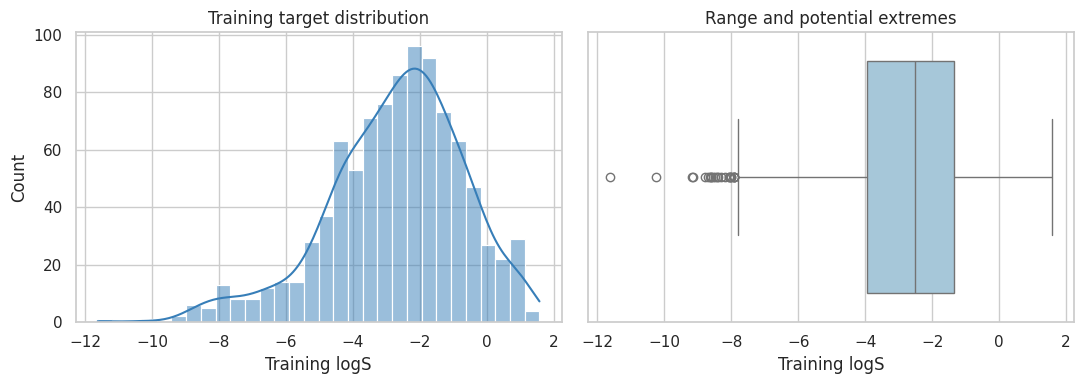

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(y_train, bins=30, kde=True, ax=axes[0], color="#377eb8")
axes[0].set(xlabel="Training logS", title="Training target distribution")
sns.boxplot(x=y_train, ax=axes[1], color="#9ecae1")
axes[1].set(xlabel="Training logS", title="Range and potential extremes")
fig.tight_layout()
plt.show()

y_train.describe().to_frame("训练集 logS").T

训练目标范围较宽，并且在低溶解度方向存在长尾，因此仅报告平均误差不够。下面使用对较大误差更敏感的 RMSE 选择模型，同时在最终测试中补充 MAE 与 R²。

## 3. 候选模型与防泄漏设计

直接建模管道比较：

- 中位数基线
- 普通线性回归
- Ridge（L2 正则化）
- Lasso（L1 正则化）
- Elastic Net（L1 + L2）

降维管道使用 `TruncatedSVD` 压缩 208 个二进制指纹，再与标准化后的 20 个分子描述符合并并训练 Ridge。与先对全体训练数据降维再交叉验证不同，这里的 SVD 在每个训练折内重新拟合。

In [5]:
direct_search, reduced_search = build_searches(
    descriptor_columns,
    fingerprint_columns,
)

direct_search.fit(X_train, y_train)
reduced_search.fit(X_train, y_train)

comparison = summarize_searches(direct_search, reduced_search)
comparison[["模型", "CV_RMSE"]].round(3)

,模型,CV_RMSE
0,Ridge,0.649
1,Elastic Net,0.651
2,Lasso,0.653
3,指纹 SVD + Ridge,0.655
4,普通线性回归,0.732
5,中位数基线,2.064


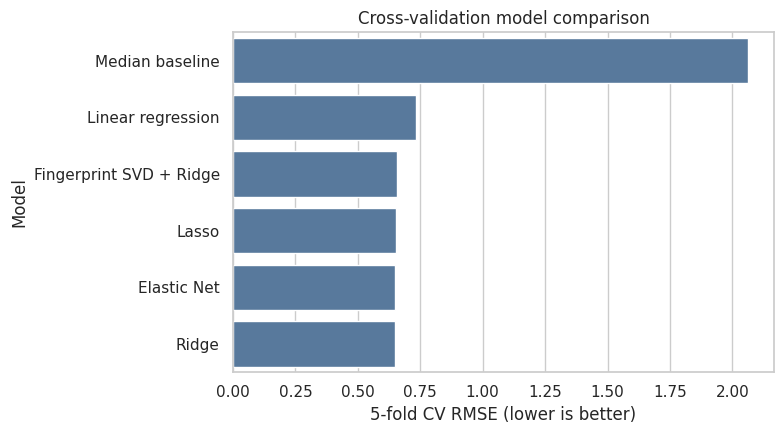

In [6]:
plt.figure(figsize=(8, 4.5))
plot_names = {
    "中位数基线": "Median baseline",
    "普通线性回归": "Linear regression",
    "指纹 SVD + Ridge": "Fingerprint SVD + Ridge",
}
plot_data = comparison.assign(Model=comparison["模型"].replace(plot_names)).sort_values(
    "CV_RMSE", ascending=False
)
sns.barplot(data=plot_data, x="CV_RMSE", y="Model", color="#4c78a8")
plt.xlabel("5-fold CV RMSE (lower is better)")
plt.ylabel("Model")
plt.title("Cross-validation model comparison")
plt.tight_layout()
plt.show()

## 4. 在查看测试结果之前确定最终模型

In [7]:
searches = [direct_search, reduced_search]
selected_search = max(searches, key=lambda search: search.best_score_)
selected_model = (
    "指纹 SVD + Ridge"
    if selected_search is reduced_search
    else model_family(selected_search.best_estimator_.named_steps["model"])
)

print(f"最终模型：{selected_model}")
print(f"交叉验证 RMSE：{-selected_search.best_score_:.3f}")
print("参数：", selected_search.best_params_)

最终模型：Ridge
交叉验证 RMSE：0.649
参数： {'model': Ridge(), 'model__alpha': 10.0}


交叉验证选择了直接使用全部特征的 Ridge。降维模型非常接近，但没有带来更低的验证误差；这说明压缩指纹可以减少维度，但同时也会损失少量与溶解度有关的信息。

## 5. 独立测试集的一次最终评估

In [8]:
test_predictions = selected_search.best_estimator_.predict(X_test)
metrics = test_metrics(y_test, test_predictions)
pd.DataFrame([metrics], index=[selected_model]).round(3)

,RMSE,MAE,R2
Ridge,0.752,0.567,0.869


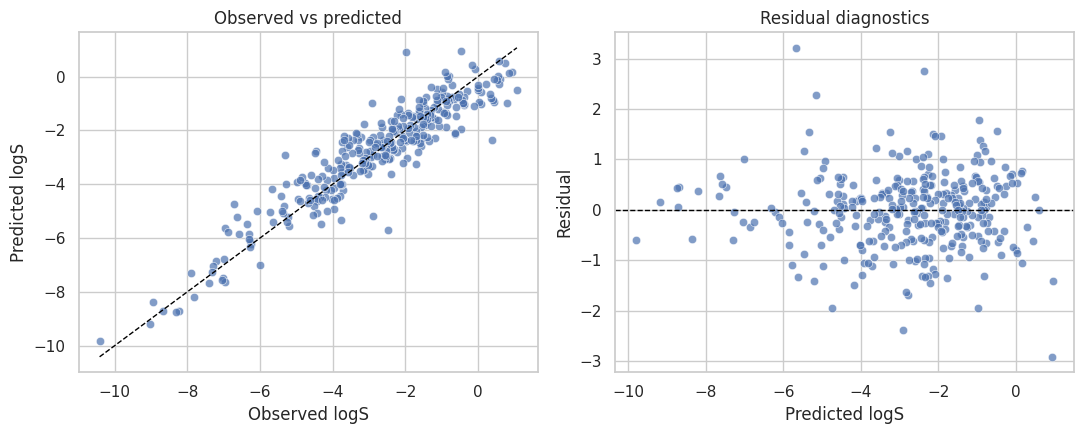

In [9]:
residuals = y_test.to_numpy() - test_predictions
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.scatterplot(x=y_test, y=test_predictions, alpha=0.7, ax=axes[0])
limits = [min(y_test.min(), test_predictions.min()), max(y_test.max(), test_predictions.max())]
axes[0].plot(limits, limits, "--", color="black", linewidth=1)
axes[0].set(xlabel="Observed logS", ylabel="Predicted logS", title="Observed vs predicted")

sns.scatterplot(x=test_predictions, y=residuals, alpha=0.7, ax=axes[1])
axes[1].axhline(0, linestyle="--", color="black", linewidth=1)
axes[1].set(xlabel="Predicted logS", ylabel="Residual", title="Residual diagnostics")
fig.tight_layout()
plt.show()

In [10]:
error_analysis = pd.DataFrame(
    {
        "真实 logS": y_test,
        "预测 logS": test_predictions,
        "残差": residuals,
        "绝对误差": np.abs(residuals),
    }
)
error_analysis.nlargest(10, "绝对误差").round(3)

,真实 logS,预测 logS,残差,绝对误差
315,-2.47,-5.686,3.216,3.216
256,-1.99,0.928,-2.918,2.918
313,0.39,-2.372,2.762,2.762
191,-5.31,-2.924,-2.386,2.386
314,-2.90,-5.170,2.270,2.270
198,-6.70,-4.745,-1.955,1.955
121,-2.92,-0.978,-1.942,1.942
2,0.81,-0.967,1.777,1.777
179,-4.47,-2.782,-1.688,1.688
292,-4.48,-2.846,-1.634,1.634


## 6. 结论

- Ridge 的 5 折交叉验证 RMSE 为约 **0.649**，优于普通线性回归的约 **0.732**，说明高维相关特征需要正则化。
- 独立测试集上，Ridge 的 RMSE 为约 **0.752**、MAE 为约 **0.567**、R² 为约 **0.869**。
- 测试 RMSE 高于交叉验证 RMSE，表明独立测试集比平均验证折更难；不应只根据 R² 宣称模型已经充分泛化。
- TruncatedSVD + Ridge 的验证 RMSE 约 **0.655**，只比完整特征 Ridge 略差，因此在推理资源受限时仍是合理备选。

进一步提高评估可信度需要分子结构标识（例如 SMILES），以便采用分子骨架分组交叉验证，减少结构相近分子跨折造成的乐观偏差。